# Custom Dataset Generator

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt


rng = np.random.default_rng(42)

In [2]:
def generate_students(n=200, seed=42):
	rng = np.random.default_rng(seed)
	hours_studied = rng.normal(5, 2, n).clip(1, 10)
	marks = (hours_studied * rng.uniform(8, 12, n) + rng.normal(0, 5, n)).clip(30, 100)
	gender = rng.choice(['Male', 'Female'], n)
	subject = rng.choice(['Math', 'Science', 'English', 'History'], n)
	study_method = rng.choice(['Solo', 'Group'], n, p=[0.6, 0.4])
	attempts = rng.integers(1, 4, n)
	return pd.DataFrame({
		'hours_studied': hours_studied.round(2),
		'marks': marks.round(2),
		'gender': gender,
		'subject': subject,
		'study_method': study_method,
		'attempts': attempts
	})

এই কোডটি মূলত একটি কৃত্তিম (Synthetic) ডেটাসেট তৈরি করার ফাংশন, যা স্টুডেন্টদের পড়ার সময় এবং তাদের প্রাপ্ত নম্বরের মধ্যে একটি সম্পর্ক দেখায়। নিচে পয়েন্ট আকারে ব্যাখ্যা দেওয়া হলো:

### **মূল কোড অ্যানালাইসিস:**

১. **`rng = np.random.default_rng(42)`**:
এখানে একটি **Random Number Generator (RNG)** অবজেক্ট তৈরি করা হয়েছে। `42` হলো একটি `seed`, যার ফলে আপনি যতবারই এই কোডটি রান করবেন, প্রতিবার একই র্যান্ডম নম্বর জেনারেট হবে।

২. **`hours_studied`**:
`rng.normal(5, 2, n)` দিয়ে একটি **Normal Distribution** (গড় ৫ ঘণ্টা, স্ট্যান্ডার্ড ডেভিয়েশন ২) তৈরি করা হয়েছে। `.clip(1, 10)` ব্যবহার করা হয়েছে যাতে পড়াশোনার সময় কোনোভাবেই ১ ঘণ্টার নিচে বা ১০ ঘণ্টার উপরে না যায়।

৩. **`marks` (লজিক্যাল সম্পর্ক)**:
এখানে মার্কস বা নম্বর জেনারেট করার জন্য একটি ইকুয়েশন ব্যবহার করা হয়েছে:
`marks = (hours_studied * rng.uniform(8, 12, n) + rng.normal(0, 5, n))`

* অর্থাৎ, কেউ যত বেশি ঘণ্টা পড়বে, তার মার্কস তত বেশি হবে।
* সাথে কিছু র্যান্ডম 'নয়েজ' বা ভ্যারিয়েশন যোগ করা হয়েছে যাতে ডেটাগুলো একদম নিখুঁত সরলরেখায় না থেকে বাস্তবসম্মত হয়।
* শেষে `.clip(30, 100)` দিয়ে মার্কস ৩০ থেকে ১০০ এর মধ্যে সীমাবদ্ধ রাখা হয়েছে।

৪. **ক্যাটাগরিক্যাল ডেটা (`gender`, `subject`, `study_method`)**:

* **`rng.choice`**: এই ফাংশনটি দিয়ে লিস্ট থেকে র্যান্ডমলি মান বেছে নেওয়া হয়েছে।
* **`p=[0.6, 0.4]`**: `study_method`-এর ক্ষেত্রে বলা হয়েছে যে ৬০% স্টুডেন্ট 'Solo' পড়বে আর ৪০% 'Group' স্টাডি করবে।

৫. **`attempts`**:
`rng.integers(1, 4, n)` দিয়ে প্রতিটি স্টুডেন্ট ১ থেকে ৩ বার পরীক্ষা দেওয়ার চেষ্টার একটি সংখ্যা জেনারেট করা হয়েছে (এখানে ৪ এক্সক্লুসিভ)।

৬. **`pd.DataFrame`**:
সবশেষে এই সবগুলোকে একটি সুন্দর টেবিল বা **Pandas DataFrame** হিসেবে রিটার্ন করা হয়েছে।

### **সারসংক্ষেপ:**

এই ফাংশনটি কল করলে আপনি ২০০ জন স্টুডেন্টের একটি পূর্ণাঙ্গ তালিকা পাবেন যেখানে তাদের পড়াশোনার ঘণ্টার সাথে প্রাপ্ত নম্বরের একটি পজিটিভ কো-রিলেশন থাকবে।

In [3]:
def generate_daily_sales(n=60, seed=42):
	rng = np.random.default_rng(seed)
	date = pd.date_range(start='2024-01-01', periods=n, freq='D')
	trend = np.linspace(50, 80, n)
	season = 8 * np.sin(np.linspace(0, 3 * np.pi, n))
	noise = rng.normal(0, 3, n)
	sales = (trend + season + noise).round(2)
	return pd.DataFrame({
		'date': date,
		'sales': sales
	})

এই ফাংশনটি মূলত একটি **Time Series** বা সময়ের সাথে পরিবর্তনশীল বিক্রয়ের ডেটাসেট (Sales Data) তৈরি করার জন্য লেখা হয়েছে। এখানে বিক্রয়ের পরিমাণের মধ্যে তিনটি প্রধান জিনিস মেশানো হয়েছে: একটি ধারাবাহিক উন্নতি (**Trend**), ওঠানামা (**Seasonality**), এবং কিছু র্যান্ডম পরিবর্তন (**Noise**)।

### **কোড অ্যানালাইসিস:**

১. **`base = pd.date_range(...)`**:
এটি ২০২৪ সালের ১লা জানুয়ারি থেকে শুরু করে টানা `n` দিনের (ডিফল্ট ৬০ দিন) একটি তারিখের লিস্ট তৈরি করবে। এটিই হবে আপনার ডেটাসেটের টাইমলাইন।

২. **`trend = np.linspace(50, 80, n)`**:
এটি একটি **Upward Trend** বা ক্রমবর্ধমান ধারা তৈরি করে। অর্থাৎ, ৬০ দিনের শুরুতে বিক্রি ৫০ থেকে শুরু হয়ে ধীরে ধীরে বেড়ে শেষ দিনে ৮০-তে পৌঁছাবে। এটি ব্যবসার দীর্ঘমেয়াদী উন্নতি বোঝাতে ব্যবহৃত হয়।

৩. **`season = 8 * np.sin(np.linspace(0, 3*np.pi, n))`**:
এটি একটি **Sinusoidal Curve** বা ঢেউয়ের মতো আকৃতি তৈরি করে। বাস্তব জীবনে যেমন ছুটির দিনে বা মাসের নির্দিষ্ট সময়ে বিক্রি বাড়ে-কমে, এই `sin` ফাংশনটি সেই ঋতুভিত্তিক পরিবর্তন বা **Seasonality** ফুটিয়ে তোলে।

৪. **`noise = rng.normal(0, 3, n)`**:
বাস্তবে কোনো ব্যবসাই একদম নিখুঁত ট্রেন্ড বা ঢেউ মেনে চলে না। প্রতিদিন কিছু ছোটখাটো অঘটন বা র্যান্ডম পরিবর্তন থাকে। এই `noise` সেই বাস্তবসম্মত এলোমেলো ভাব যোগ করে।

৫. **`sales = (trend + season + noise).round(2)`**:
সবশেষে ট্রেন্ড, সিজন এবং নয়েজ—এই তিনটি যোগ করে চূড়ান্ত `sales` বা বিক্রয়ের পরিমাণ বের করা হয়েছে। এর ফলে এমন একটি ডেটা তৈরি হয় যা দেখতে একদম আসল বিক্রয়ের গ্রাফের মতো।

### **কেন এটি দরকার?**

এই ধরণের সিনথেটিক ডেটা দিয়ে আপনি শিখতে পারবেন:

* কীভাবে সময়ের সাথে ডেটার পরিবর্তন ভিজ্যুয়ালাইজ করতে হয়।
* কীভাবে বড় কোনো ট্রেন্ড থেকে সিজনাল ওঠানামা আলাদা করতে হয়।

In [4]:
# Example usage
students_df = generate_students(220)
students_df.head()

,hours_studied,marks,gender,subject,study_method,attempts
0,5.61,54.04,Male,English,Solo,2
1,2.92,30.00,Female,Science,Solo,2
2,6.50,70.46,Female,History,Group,3
3,6.88,52.76,Female,English,Group,3
4,1.10,30.00,Female,History,Solo,1


In [5]:
# Example usage
sales_df = generate_daily_sales(90)
sales_df.head()

,date,sales
0,2024-01-01,50.91
1,2024-01-02,48.06
2,2024-01-03,54.61
3,2024-01-04,56.33
4,2024-01-05,48.78


# Practice Problem Solution 01
* Using sales, draw a lineplot of date vs. sales.

In [6]:
# Now we'll draw a Line plot, of the DataFrame 'sales_df', using Plotly, where x-axis will represent the column 'date' and y-axis will represent the column 'sales'.

px.line(
	data_frame=sales_df,
	x='date',
	y='sales',
	title='Analytics between date and sales',
	width=1000,
	height=500,
).show()

# Practice Problem Solution 02
* From students, plot hours_studied vs marks and color by gender.

In [7]:
# Now we'll create a scatterplot using Plotly, with the DataFrame 'students_df', where x-axis will represent the column 'hours_studied' and y-axis will represent the column 'marks'.
# We'll also color the points by the column 'gender'.

px.scatter(
	data_frame=students_df,
	x='hours_studied',
	y='marks',
	color='gender',
	title='Analytics between hours_studied and marks',
	width=1000,
	height=500
).show()

# Practice Problem Solution 03
* Create a grid of scatter plots (hours_studied vs marks) faceted by the subject.

In [8]:
# Now we'll create a grid of Scatter plots, using Plotly, with the dataFrame 'students_df', where x-axis will represent the column 'hours_studied' and y-axis will represent the column 'marks'.

px.scatter(
	data_frame=students_df,
	x='hours_studied',
	y='marks',
	facet_col='subject',
	color='gender',
	title='Analytics between hours_studied and marks',
	height=500
).show()

# Practice Problem Solution 04
* Plot a histogram of marks with a KDE overlay.

<Axes: xlabel='marks', ylabel='Count'>

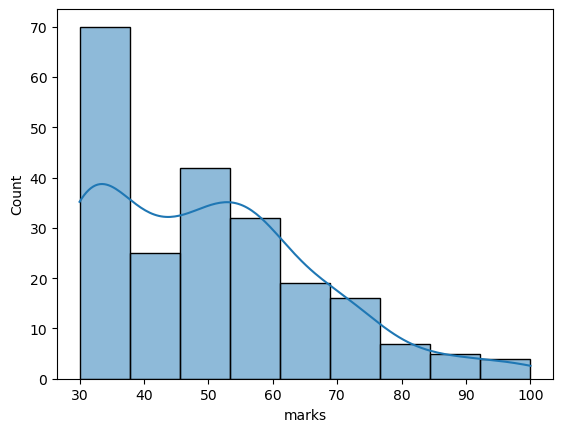

In [9]:
# Now we'll create a Histogram, using Plotly, with the DataFrame 'students_df', where x-axis will represent the column 'marks' and y-axis will represent the count of marks, and KDE overlay will be enabled.
# px.histogram(
# 	data_frame=students_df,
# 	x='marks',
# 	title='Histogram of Marks',
# 	width=1000,
# 	height=500,
# ).show()


# But Plotly doesn't have a KDE overlay, so we'll use Seaborn instead.


# Now we'll create a Histogram, using Seaborn, with the DataFrame 'students_df', where x-axis will represent the column 'marks' and y-axis will represent the count of marks, and KDE overlay will be enabled.
sns.histplot(
    data=students_df,
    x='marks',
    kde=True
)

# Practice Problem Solution 05
* Show the KDE curve for hours_studied.

<Axes: xlabel='hours_studied', ylabel='Count'>

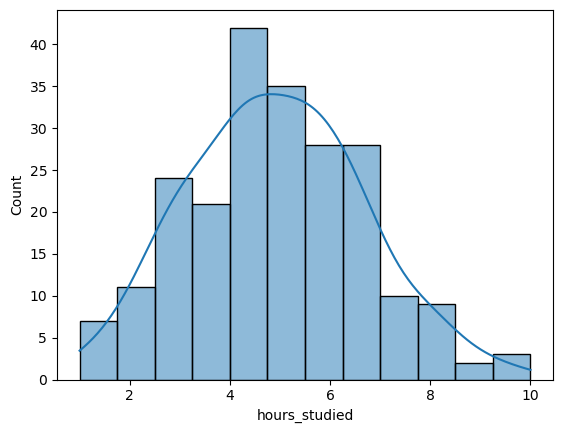

In [10]:
# Now we'll create a Histogram, using Seaborn, with the DataFrame 'students_df', where x-axis will represent the column 'hours_studied' and y-axis will represent the count of hours_studied, and KDE overlay will be enabled.

sns.histplot(
	data=students_df,
	x='hours_studied',
	kde=True,
)

# Practice Problem Solution 06
* Display the count of records per subject.

In [11]:
# Now we'll create a Histogram, using Plotly, with the DataFrame 'students_df', where the x-axis will represent the column 'subject'.

px.histogram(
	data_frame=students_df,
	x='subject',
	title='Count of records per subject',
	color='subject',
	width=1000,
	height=500,
).show()

# Practice Problem Solution 07
* Draw a regression line for hours_studied and marks.

Text(0, 0.5, 'Marks')

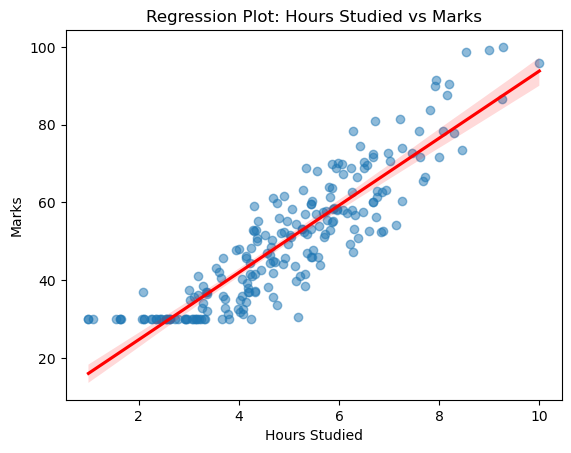

In [12]:
# Now we'll create a Regression plot, using Plotly, where the dataFrame will be 'students_df', and x-axis will represent the column 'hours_studied' and y-axis will represent the column 'marks'.
# px.scatter(data_frame=students_df, x='hours_studied', y='marks', title='Regression line for hours_studied and marks').show()


# But Plotly can't do the mathematical calculation of Regression plot without an additional paython package, so we'll use Seaborn instead.


# Now we'll create a Regression plot, using Seaborn, where the dataFrame will be 'students_df', and x-axis will represent the column 'hours_studied' and y-axis will represent the column 'marks'.
sns.regplot(
	data=students_df,
	x='hours_studied',
	y='marks',
	scatter_kws={'alpha': 0.5},
	line_kws={'color': 'red'}
)
plt.title('Regression Plot: Hours Studied vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks')

# Practice Problem Solution 08
* Create a Pair plot and a Joint plot for students' dataset.

In [13]:
# Let's see the DataFrame once again.

students_df.head()

,hours_studied,marks,gender,subject,study_method,attempts
0,5.61,54.04,Male,English,Solo,2
1,2.92,30.00,Female,Science,Solo,2
2,6.50,70.46,Female,History,Group,3
3,6.88,52.76,Female,English,Group,3
4,1.10,30.00,Female,History,Solo,1


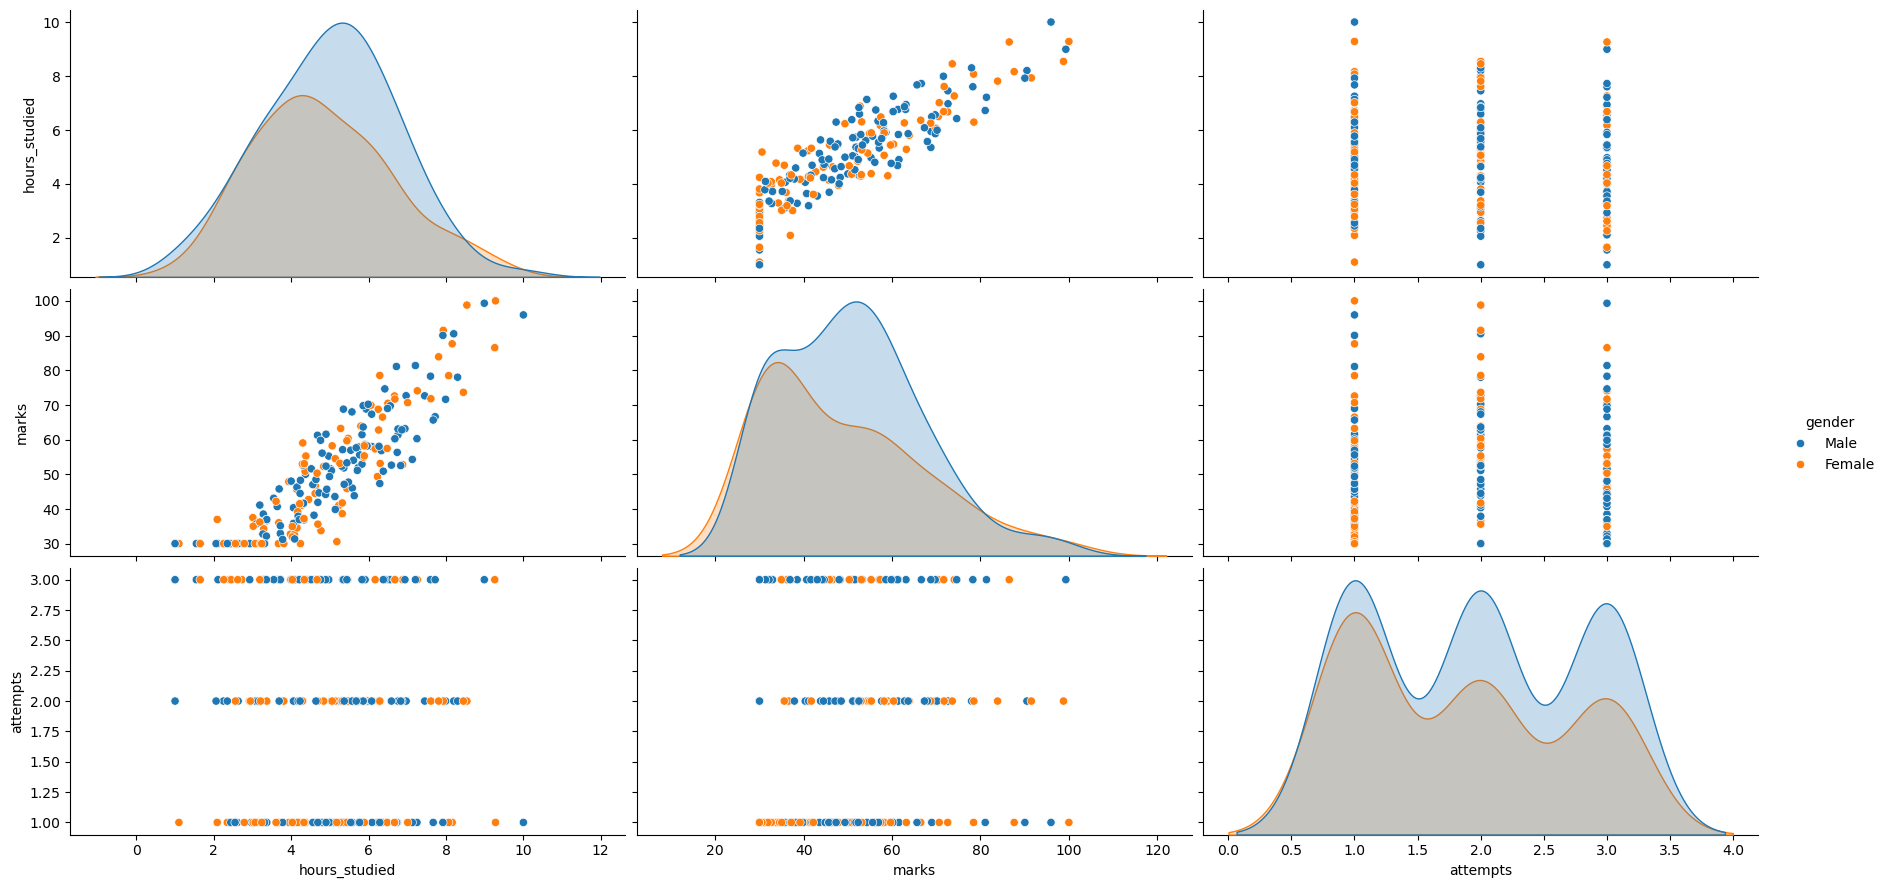

In [14]:
# Now we'll create a Pair plot, using Seaborn, with the DataFrame 'students_df', where x-axis will represent all the columns consisting of numeric values and y-axis will represent all the columns consisting of numeric values.
sns.pairplot(students_df, hue='gender', height=3, aspect=2)


# We also can use the 'corner' parameter to remove the duplicate plots.
# sns.pairplot(students_df, hue='gender', height=3, aspect=2, corner=True)

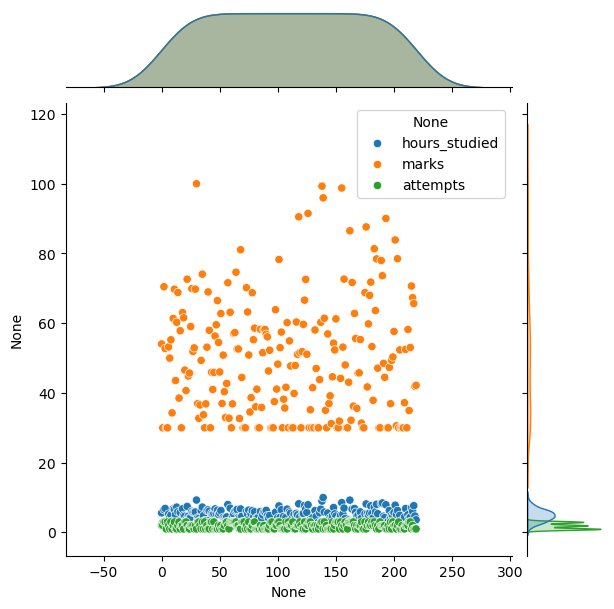

In [22]:
# Now we'll create a Joint plot, using Seaborn, with the DataFrame 'students_df', where x-axis will represent all the columns consisting of numeric values and y-axis will represent all the columns consisting of numeric values.

sns.jointplot(data=students_df)

# Practice Problem Solution 09
* Make a scatter plot of hours_studied vs. marks using Plotly, colored by gender.

In [26]:
# Now we'll create a Scatter plot, using Plotly, where the dataFrame will be 'students_df', and x-axis will represent the column 'hours_studied' and y-axis will represent the column 'marks', and color parameter will represent the column 'gender'.

px.scatter(
    data_frame=students_df,
    x='hours_studied',
    y='marks',
    color='gender',
    title='Analytics between hours_studied and marks among Male and Female students',
    width=1000,
    height=500
).show()

# Practice Problem Solution 10
* Draw a line chart of sales over date and a histogram of marks using Plotly.

In [29]:
# Now we'll create a Line plot, using Plotly, where the DataFrame will be 'sales_df', and x-axis will represent the column 'date' and y-axis will represent the column 'sales'.

px.line(
	data_frame=sales_df,
	x='date',
	y='sales',
	title='Analytics of Sales over date',
	width=1000,
	height=500
).show()

---